# Лабораторная работа №4  
## Поиск ассоциативных правил в транзакционных данных

**Дисциплина:** Интеллектуальный анализ данных  
**Используемые датасеты:**

1. `blink_cleaned.csv` — скачанный и предварительно очищенный от пропусков датасет.
2. `lab3_dimensionality_dataset.csv` — синтетический датасет.

В работе реализуются два алгоритма поиска частых наборов и ассоциативных правил:

- **Apriori**;
- **FP-Growth**.

Готовые реализации из библиотек `mlxtend`, `pyfpgrowth`, `efficient_apriori` не используются.


## Цель работы

Освоить методы поиска ассоциативных правил, реализовать ключевые алгоритмы Apriori и FP-Growth, применить их к подготовленным данным, провести сравнение производительности и интерпретировать найденные правила.

Важное замечание по данным: оба исходных файла не являются «корзинами покупок» в готовом виде. Поэтому каждая строка датасета преобразуется в транзакцию: категориальные признаки становятся элементами вида `признак=значение`, а числовые признаки разбиваются на интервалы `низкий`, `средний`, `высокий`.

In [20]:
import os
import math
import time
import random
from itertools import combinations, chain
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Загрузка данных

In [21]:
def load_csv(filename):
    """Загружает CSV из нескольких возможных директорий."""
    possible_paths = [
        filename,
        os.path.join('/content', filename),
        os.path.join('/mnt/data', filename),
    ]
    for path in possible_paths:
        if os.path.exists(path):
            print(f'Файл найден: {path}')
            return pd.read_csv(path)
    raise FileNotFoundError(f'Не найден файл: {filename}')

blink = load_csv('blink_cleaned.csv')
lab3 = load_csv('lab3_dimensionality_dataset.csv')

print('Размер blink_cleaned:', blink.shape)
print('Размер lab3_dimensionality_dataset:', lab3.shape)

display(blink.head())
display(lab3.head())

Файл найден: blink_cleaned.csv
Файл найден: lab3_dimensionality_dataset.csv
Размер blink_cleaned: (608, 15)
Размер lab3_dimensionality_dataset: (700, 22)


,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA,timestampToA_clean,timestampToA_missing_ind,Timestamp ToA_clean,Timestamp ToA_missing_ind,wrap_count,Timestamp ToA_unwrapped,timestampToA_unwrapped
0,1,ANCH0001,TAG00001,0,0,1,"728,480,000,000.0000",728480463493,"728,480,000,000.0000",0,"728,480,463,493.0000",0,0,"728,480,463,493.0000","728,480,000,000.0000"
1,2,ANCH0004,TAG00001,0,0,1,"728,480,000,000.0000",728480463235,"728,480,000,000.0000",0,"728,480,463,235.0000",0,0,"728,480,463,235.0000","728,480,000,000.0000"
2,3,ANCH0002,TAG00001,0,0,1,"728,480,000,000.0000",728480462804,"728,480,000,000.0000",0,"728,480,462,804.0000",0,0,"728,480,462,804.0000","728,480,000,000.0000"
3,4,ANCH0003,TAG00001,0,0,1,"728,480,000,000.0000",728480463013,"728,480,000,000.0000",0,"728,480,463,013.0000",0,0,"728,480,463,013.0000","728,480,000,000.0000"
4,5,ANCH0001,TAG00001,1,0,1,"759,054,000,000.0000",759053775951,"759,054,000,000.0000",0,"759,053,775,951.0000",0,0,"759,053,775,951.0000","759,054,000,000.0000"


,customer_id,customer_segment,age,annual_income,monthly_expenses,monthly_savings,credit_score,debt_ratio,monthly_purchases,avg_order_value,site_visits,app_sessions,support_tickets,satisfaction_score,loyalty_score,churn_risk,time_on_platform_months,promo_response_rate,returns_count,delivery_delay_days,device_score,engagement_index
0,C0416,premium,43.0000,"49,537.8700","2,012.5700","2,367.3800",690.0000,0.2980,9.0000,46.0500,49.0000,26.0000,2.0000,7.7300,54.8300,15.3100,29.0000,0.1670,3.0000,1.8300,74.0200,50.9300
1,C0509,premium,32.0000,"61,281.1200","2,536.3700","2,932.7400",711.0000,0.1450,14.0000,63.1900,61.0000,42.0000,0.0000,9.1900,80.8200,0.0000,45.0000,0.3120,2.0000,1.4000,76.8100,65.4400
2,C0244,standard,45.0000,"38,791.4400","1,572.3400","1,479.9500",570.0000,0.4600,9.0000,50.9100,53.0000,31.0000,3.0000,6.6700,54.7200,34.5700,21.0000,0.2330,3.0000,2.4900,51.3800,54.8100
3,C0186,standard,43.0000,"55,760.8300","2,356.6700","2,537.1400",703.0000,0.2510,16.0000,55.4700,78.0000,69.0000,1.0000,10.0000,87.0400,0.0000,43.0000,0.3710,4.0000,1.2700,68.4600,100.0000
4,C0643,risk_group,40.0000,"46,410.2200","1,865.0000","1,992.7500",624.0000,0.4390,8.0000,45.6300,31.0000,38.0000,3.0000,6.4700,62.1900,43.6500,28.0000,0.2650,1.0000,2.2000,68.2000,54.8400


## 2. Краткое профилирование датасетов

Перед поиском правил посмотрим на типы данных, пропуски и количество уникальных значений. Это нужно, чтобы корректно превратить обычную таблицу в набор транзакций.

In [22]:
def profile_dataframe(df, name):
    """Выводит краткое описание датасета."""
    print(f'===== {name} =====')
    print('Размер:', df.shape)
    print('\nТипы данных:')
    display(df.dtypes.to_frame('dtype').T)

    profile = pd.DataFrame({
        'missing': df.isna().sum(),
        'missing_share': df.isna().mean(),
        'n_unique': df.nunique(dropna=False)
    }).sort_values(['missing', 'n_unique'], ascending=False)
    display(profile)

profile_dataframe(blink, 'blink_cleaned')
profile_dataframe(lab3, 'lab3_dimensionality_dataset')

===== blink_cleaned =====
Размер: (608, 15)

Типы данных:


,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA,timestampToA_clean,timestampToA_missing_ind,Timestamp ToA_clean,Timestamp ToA_missing_ind,wrap_count,Timestamp ToA_unwrapped,timestampToA_unwrapped
dtype,int64,object,object,int64,int64,int64,float64,int64,float64,int64,float64,int64,int64,float64,float64


,missing,missing_share,n_unique
Timestamp ToA_clean,5,0.0082,602
Timestamp ToA_unwrapped,5,0.0082,602
timestampToA_clean,5,0.0082,189
timestampToA_unwrapped,5,0.0082,189
id,0,0.0000,608
Timestamp ToA,0,0.0000,602
timestampToA,0,0.0000,189
sequenceID,0,0.0000,164
wrap_count,0,0.0000,6
anchorID,0,0.0000,4


===== lab3_dimensionality_dataset =====
Размер: (700, 22)

Типы данных:


,customer_id,customer_segment,age,annual_income,monthly_expenses,monthly_savings,credit_score,debt_ratio,monthly_purchases,avg_order_value,site_visits,app_sessions,support_tickets,satisfaction_score,loyalty_score,churn_risk,time_on_platform_months,promo_response_rate,returns_count,delivery_delay_days,device_score,engagement_index
dtype,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


,missing,missing_share,n_unique
credit_score,7,0.0100,317
monthly_savings,6,0.0086,694
loyalty_score,6,0.0086,654
satisfaction_score,6,0.0086,413
app_sessions,6,0.0086,97
annual_income,5,0.0071,677
delivery_delay_days,5,0.0071,314
support_tickets,5,0.0071,12
customer_id,0,0.0000,700
monthly_expenses,0,0.0000,689


## 3. Теоретическая часть

Ассоциативное правило имеет вид:

$$X \rightarrow Y,$$

где `X` — левая часть правила, `Y` — правая часть правила.

Для правила $X \rightarrow Y$ используются метрики:

$$support(X \cup Y) = \frac{\text{число транзакций с } X \cup Y}{\text{общее число транзакций}}$$

$$confidence(X \rightarrow Y) = \frac{support(X \cup Y)}{support(X)}$$

$$lift(X \rightarrow Y) = \frac{confidence(X \rightarrow Y)}{support(Y)}$$

$$leverage(X \rightarrow Y) = support(X \cup Y) - support(X) \cdot support(Y)$$

$$conviction(X \rightarrow Y) = \frac{1 - support(Y)}{1 - confidence(X \rightarrow Y)}$$

Интерпретация:

- `support` показывает, насколько часто набор встречается в данных;
- `confidence` показывает, насколько часто правая часть встречается при наличии левой;
- `lift > 1` означает положительную связь между левой и правой частью;
- `leverage > 0` означает, что совместное появление чаще, чем при независимости;
- `conviction` показывает силу направленного правила, особенно когда `confidence` близка к 1.

## 4. Реализация Apriori

Идея Apriori основана на свойстве антимонотонности: если набор не является частым, то все его надмножества тоже не могут быть частыми.

Алгоритм строит частые наборы постепенно: сначала одиночные элементы, затем пары, затем тройки и так далее.

In [23]:
def normalize_transactions(transactions):
    """Преобразует транзакции к списку множеств и удаляет пустые транзакции."""
    return [set(t) for t in transactions if len(t) > 0]


def support_threshold(min_support, n_transactions):
    """
    Переводит min_support в минимальное абсолютное число транзакций.
    Если min_support задан долей от 0 до 1, используется ceil(min_support * N).
    """
    if isinstance(min_support, float) and 0 < min_support <= 1:
        return math.ceil(min_support * n_transactions)
    return int(min_support)


def apriori_gen(prev_frequent, k):
    """Генерация кандидатов размера k из частых наборов размера k-1."""
    prev_frequent = sorted(prev_frequent)
    prev_set = set(prev_frequent)
    candidates = set()

    for i in range(len(prev_frequent)):
        for j in range(i + 1, len(prev_frequent)):
            a = prev_frequent[i]
            b = prev_frequent[j]

            if a[:k - 2] != b[:k - 2]:
                break

            candidate = tuple(sorted(set(a) | set(b)))

            if len(candidate) == k:
                all_subsets_frequent = all(
                    tuple(sorted(subset)) in prev_set
                    for subset in combinations(candidate, k - 1)
                )
                if all_subsets_frequent:
                    candidates.add(candidate)

    return candidates


def apriori(transactions, min_support, max_len=None):
    """
    Реализация алгоритма Apriori.

    Параметры:
    transactions: список транзакций, каждая транзакция — список или множество элементов;
    min_support: минимальная поддержка, доля от 0 до 1 или абсолютное число;
    max_len: максимальный размер частого набора. Если None, ограничение не задается.

    Возвращает:
    словарь {itemset_tuple: support_value}.
    """
    transactions = normalize_transactions(transactions)
    n_transactions = len(transactions)
    min_count = support_threshold(min_support, n_transactions)

    item_counts = Counter()
    for transaction in transactions:
        item_counts.update(transaction)

    current_frequent = {
        (item,): count / n_transactions
        for item, count in item_counts.items()
        if count >= min_count
    }
    current_frequent = dict(sorted(current_frequent.items()))

    frequent_itemsets = dict(current_frequent)
    prev_frequent = set(current_frequent.keys())

    k = 2
    while prev_frequent and (max_len is None or k <= max_len):
        candidates = apriori_gen(prev_frequent, k)
        if not candidates:
            break

        candidate_counts = Counter()

        # Вместо проверки каждого кандидата против каждой транзакции
        # генерируем комбинации элементов внутри транзакции.
        for transaction in transactions:
            if len(transaction) >= k:
                for combo in combinations(sorted(transaction), k):
                    if combo in candidates:
                        candidate_counts[combo] += 1

        current_frequent = {
            candidate: count / n_transactions
            for candidate, count in candidate_counts.items()
            if count >= min_count
        }
        current_frequent = dict(sorted(current_frequent.items()))

        frequent_itemsets.update(current_frequent)
        prev_frequent = set(current_frequent.keys())
        k += 1

    return dict(sorted(frequent_itemsets.items(), key=lambda x: (len(x[0]), x[0])))

## 5. Генерация ассоциативных правил

После нахождения частых наборов из каждого набора длины 2 и больше можно строить правила. В лабораторной работе дополнительно требуется ограничивать максимальную длину левой и правой части правила. Это реализовано через параметры `max_antecedent_len` и `max_consequent_len`.

In [24]:
def generate_rules(
    frequent_itemsets,
    min_confidence,
    min_lift=1.0,
    max_antecedent_len=3,
    max_consequent_len=1
):
    """Генерирует ассоциативные правила по словарю частых наборов."""
    rules = []
    support_lookup = {tuple(itemset): support for itemset, support in frequent_itemsets.items()}

    for itemset, support_itemset in support_lookup.items():
        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)

        for r in range(1, len(itemset)):
            for antecedent in combinations(itemset, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                if len(antecedent) > max_antecedent_len:
                    continue
                if len(consequent) > max_consequent_len:
                    continue

                support_antecedent = support_lookup.get(antecedent)
                support_consequent = support_lookup.get(consequent)

                if support_antecedent is None or support_consequent is None:
                    continue

                confidence = support_itemset / support_antecedent
                lift = confidence / support_consequent if support_consequent > 0 else np.inf
                leverage = support_itemset - support_antecedent * support_consequent
                conviction = np.inf if abs(1 - confidence) < 1e-12 else (1 - support_consequent) / (1 - confidence)

                if confidence >= min_confidence and lift >= min_lift:
                    rules.append({
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support': support_itemset,
                        'confidence': confidence,
                        'lift': lift,
                        'conviction': conviction,
                        'leverage': leverage
                    })

    return sorted(rules, key=lambda x: (x['lift'], x['confidence'], x['support']), reverse=True)


def itemset_to_str(itemset):
    """Красивое текстовое представление набора элементов."""
    return ' + '.join(itemset)


def rules_to_frame(rules, top_n=10, sort_by='lift'):
    """Преобразует список правил в DataFrame для вывода."""
    rows = []
    for rule in rules:
        rows.append({
            'antecedent': itemset_to_str(rule['antecedent']),
            'consequent': itemset_to_str(rule['consequent']),
            'support': rule['support'],
            'confidence': rule['confidence'],
            'lift': rule['lift'],
            'conviction': rule['conviction'],
            'leverage': rule['leverage']
        })

    df_rules = pd.DataFrame(rows)
    if df_rules.empty:
        return df_rules
    return df_rules.sort_values(sort_by, ascending=False).head(top_n)

## 6. Реализация FP-Growth

FP-Growth строит компактное FP-дерево. В отличие от Apriori, алгоритм не генерирует большое количество кандидатов напрямую. Он сжимает транзакции в дерево и затем рекурсивно строит условные деревья.

In [25]:
class FPNode:
    """Узел FP-дерева."""
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

    def increment(self, count):
        """Увеличивает счетчик узла."""
        self.count += count


def _update_header(node, header_entry):
    """Добавляет узел в горизонтальную цепочку node_link для конкретного элемента."""
    if header_entry[1] is None:
        header_entry[1] = node
    else:
        current = header_entry[1]
        while current.node_link is not None:
            current = current.node_link
        current.node_link = node


def _insert_tree(items, node, header_table, count=1):
    """Вставляет отсортированную транзакцию в FP-дерево."""
    if not items:
        return

    first = items[0]

    if first in node.children:
        node.children[first].increment(count)
    else:
        new_node = FPNode(first, count, node)
        node.children[first] = new_node
        _update_header(new_node, header_table[first])

    _insert_tree(items[1:], node.children[first], header_table, count)


def _to_weighted_transactions(transactions):
    """Приводит транзакции к формату [(set(items), count), ...]."""
    weighted = []
    for obj in transactions:
        if isinstance(obj, tuple) and len(obj) == 2 and isinstance(obj[1], int):
            items, count = obj
            items = set(items)
            if items and count > 0:
                weighted.append((items, count))
        else:
            items = set(obj)
            if items:
                weighted.append((items, 1))
    return weighted


def _build_fptree(transactions, min_count):
    """Строит FP-дерево и header table."""
    weighted_transactions = _to_weighted_transactions(transactions)

    item_counts = Counter()
    for transaction, count in weighted_transactions:
        for item in transaction:
            item_counts[item] += count

    frequent_items = {item: count for item, count in item_counts.items() if count >= min_count}
    if not frequent_items:
        return None, None

    header_table = {item: [count, None] for item, count in frequent_items.items()}
    root = FPNode(None, 0, None)

    def order_key(item):
        return (-frequent_items[item], item)

    for transaction, count in weighted_transactions:
        ordered_items = [item for item in sorted((x for x in transaction if x in frequent_items), key=order_key)]
        if ordered_items:
            _insert_tree(ordered_items, root, header_table, count)

    return root, header_table


def _prefix_path(node):
    """Возвращает путь от корня до родителя текущего узла."""
    path = []
    current = node.parent
    while current is not None and current.item is not None:
        path.append(current.item)
        current = current.parent
    path.reverse()
    return path


def fpgrowth(transactions, min_support, max_len=None):
    """Реализация алгоритма FP-Growth. Возвращает словарь {itemset_tuple: support_value}."""
    base_transactions = normalize_transactions(transactions)
    n_transactions = len(base_transactions)
    min_count = support_threshold(min_support, n_transactions)

    _, header_table = _build_fptree(base_transactions, min_count)
    if header_table is None:
        return {}

    result_counts = {}

    def mine(header, suffix):
        sorted_items = sorted(header.items(), key=lambda x: (x[1][0], x[0]))

        for item, (count, node) in sorted_items:
            new_itemset = tuple(sorted(set(suffix) | {item}))

            if max_len is None or len(new_itemset) <= max_len:
                result_counts[new_itemset] = count

            if max_len is not None and len(new_itemset) >= max_len:
                continue

            conditional_patterns = []
            current = node
            while current is not None:
                path = _prefix_path(current)
                if path:
                    conditional_patterns.append((path, current.count))
                current = current.node_link

            if conditional_patterns:
                _, conditional_header = _build_fptree(conditional_patterns, min_count)
                if conditional_header is not None:
                    mine(conditional_header, set(new_itemset))

    mine(header_table, set())

    return dict(sorted(
        {itemset: count / n_transactions for itemset, count in result_counts.items()}.items(),
        key=lambda x: (len(x[0]), x[0])
    ))

## 7. Проверка корректности на маленьком примере

Перед применением к датасетам проверим, что Apriori и FP-Growth находят одинаковые частые наборы на небольшом наборе транзакций.

In [26]:
test_transactions = [
    {'A', 'B', 'C'},
    {'A', 'B'},
    {'A', 'C'},
    {'B', 'C'},
    {'A', 'B', 'C'}
]

test_apriori = apriori(test_transactions, min_support=0.4, max_len=3)
test_fp = fpgrowth(test_transactions, min_support=0.4, max_len=3)

print('Частые наборы Apriori:')
display(pd.DataFrame([{'itemset': itemset_to_str(k), 'support': v} for k, v in test_apriori.items()]))

print('Частые наборы FP-Growth:')
display(pd.DataFrame([{'itemset': itemset_to_str(k), 'support': v} for k, v in test_fp.items()]))

print('Наборы совпадают:', test_apriori == test_fp)

Частые наборы Apriori:


,itemset,support
0,A,0.8000
1,B,0.8000
2,C,0.8000
3,A + B,0.6000
4,A + C,0.6000
5,B + C,0.6000
6,A + B + C,0.4000


Частые наборы FP-Growth:


,itemset,support
0,A,0.8000
1,B,0.8000
2,C,0.8000
3,A + B,0.6000
4,A + C,0.6000
5,B + C,0.6000
6,A + B + C,0.4000


Наборы совпадают: True


## 8. Подготовка данных к транзакционному виду

Так как исходные данные представлены в виде таблиц, нужно превратить каждую строку в транзакцию.

Принцип преобразования:

- категориальный признак `anchorID = ANCH0001` становится элементом `anchorID=ANCH0001`;
- числовой признак разбивается на квантили: `низкий`, `средний`, `высокий`;
- пропуски превращаются в отдельный элемент `признак=missing`;
- уникальные идентификаторы строк не используются, так как они не дают повторяющихся закономерностей.

In [27]:
def make_transactions_from_dataframe(df, categorical_cols=None, numeric_cols=None, exclude_cols=None, q=3, max_categories=20):
    """Преобразует строки DataFrame в транзакции."""
    categorical_cols = list(categorical_cols or [])
    numeric_cols = list(numeric_cols or [])
    exclude_cols = set(exclude_cols or [])

    label_map = {
        2: ['низкий', 'высокий'],
        3: ['низкий', 'средний', 'высокий'],
        4: ['очень_низкий', 'низкий', 'высокий', 'очень_высокий']
    }

    prepared_series = {}

    for col in categorical_cols:
        if col in exclude_cols or col not in df.columns:
            continue
        s = df[col]
        n_unique = s.nunique(dropna=True)
        if n_unique <= 1 or n_unique > max_categories:
            continue
        prepared_series[col] = (
            s.astype('object')
             .where(s.notna(), 'missing')
             .astype(str)
             .map(lambda v: f'{col}={v}')
        )

    for col in numeric_cols:
        if col in exclude_cols or col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        n_unique = s.nunique(dropna=True)
        if n_unique <= 1:
            continue

        if n_unique <= max_categories and n_unique <= 10:
            prepared_series[col] = (
                s.astype('object')
                 .where(s.notna(), 'missing')
                 .astype(str)
                 .map(lambda v: f'{col}={v}')
            )
        else:
            bins = min(q, int(n_unique))
            labels = label_map.get(bins, [f'bin_{i + 1}' for i in range(bins)])
            binned = pd.Series(index=df.index, dtype='object')
            notna = s.notna()
            ranked = s[notna].rank(method='first')
            try:
                binned.loc[notna] = pd.qcut(ranked, q=bins, labels=labels)
            except ValueError:
                binned.loc[notna] = pd.cut(ranked, bins=bins, labels=labels, include_lowest=True)
            binned.loc[~notna] = 'missing'
            prepared_series[col] = binned.astype(str).map(lambda v: f'{col}={v}')

    transactions = []
    for idx in df.index:
        transaction = set(series.loc[idx] for series in prepared_series.values())
        transactions.append(transaction)

    return transactions, list(prepared_series.keys())


def transaction_statistics(transactions):
    """Возвращает базовую статистику по транзакциям."""
    lengths = np.array([len(t) for t in transactions])
    item_counts = Counter(chain.from_iterable(transactions))
    stats = pd.DataFrame({
        'metric': [
            'Количество транзакций',
            'Количество уникальных элементов',
            'Средняя длина транзакции',
            'Минимальная длина транзакции',
            'Максимальная длина транзакции'
        ],
        'value': [
            len(transactions),
            len(item_counts),
            lengths.mean(),
            lengths.min(),
            lengths.max()
        ]
    })
    top_items = pd.DataFrame(item_counts.most_common(15), columns=['item', 'count'])
    top_items['support'] = top_items['count'] / len(transactions)
    return stats, top_items

## 9. Транзакции для `blink_cleaned.csv`

Для `blink_cleaned.csv` используются признаки, которые могут давать повторяющиеся закономерности: `anchorID`, `processed_flag`, индикаторы пропусков, `wrap_count` и интервальные версии временных признаков.

Признаки `id`, `tagID`, `pan` не используются: `id` уникален, а `tagID` и `pan` в данном файле фактически константны, поэтому они создавали бы очевидные правила.

In [28]:
blink_work = blink.copy()
blink_work['toa_gap'] = blink_work['Timestamp ToA_unwrapped'] - blink_work['timestampToA_unwrapped']

blink_categorical = [
    'anchorID',
    'processed_flag',
    'timestampToA_missing_ind',
    'Timestamp ToA_missing_ind',
    'wrap_count'
]

blink_numeric = [
    'sequenceID',
    'Timestamp ToA_unwrapped',
    'timestampToA_unwrapped',
    'toa_gap'
]

blink_transactions, blink_used_features = make_transactions_from_dataframe(
    blink_work,
    categorical_cols=blink_categorical,
    numeric_cols=blink_numeric,
    q=3
)

print('Использованные признаки blink_cleaned:')
print(blink_used_features)

blink_stats, blink_top_items = transaction_statistics(blink_transactions)
print('\nБазовая статистика транзакций blink_cleaned:')
display(blink_stats)

print('Топ элементов по поддержке:')
display(blink_top_items)

Использованные признаки blink_cleaned:
['anchorID', 'processed_flag', 'timestampToA_missing_ind', 'Timestamp ToA_missing_ind', 'wrap_count', 'sequenceID', 'Timestamp ToA_unwrapped', 'timestampToA_unwrapped', 'toa_gap']

Базовая статистика транзакций blink_cleaned:


,metric,value
0,Количество транзакций,608.0000
1,Количество уникальных элементов,31.0000
2,Средняя длина транзакции,9.0000
3,Минимальная длина транзакции,9.0000
4,Максимальная длина транзакции,9.0000


Топ элементов по поддержке:


,item,count,support
0,Timestamp ToA_missing_ind=0,603,0.9918
1,timestampToA_missing_ind=0,603,0.9918
2,processed_flag=1,567,0.9326
3,sequenceID=низкий,203,0.3339
4,sequenceID=высокий,203,0.3339
5,sequenceID=средний,202,0.3322
6,timestampToA_unwrapped=низкий,201,0.3306
7,Timestamp ToA_unwrapped=низкий,201,0.3306
8,toa_gap=высокий,201,0.3306
9,toa_gap=низкий,201,0.3306


## 10. Транзакции для `lab3_dimensionality_dataset.csv`

`lab3_dimensionality_dataset.csv` используется как синтетический набор данных. Каждая строка описывает условного клиента. Для поиска правил каждая строка преобразуется в транзакцию из характеристик клиента.

In [29]:
lab3_categorical = ['customer_segment']

lab3_numeric = [
    'age',
    'annual_income',
    'monthly_expenses',
    'monthly_savings',
    'credit_score',
    'debt_ratio',
    'monthly_purchases',
    'avg_order_value',
    'site_visits',
    'app_sessions',
    'support_tickets',
    'satisfaction_score',
    'loyalty_score',
    'churn_risk',
    'time_on_platform_months',
    'promo_response_rate',
    'returns_count',
    'delivery_delay_days',
    'device_score',
    'engagement_index'
]

lab3_transactions, lab3_used_features = make_transactions_from_dataframe(
    lab3,
    categorical_cols=lab3_categorical,
    numeric_cols=lab3_numeric,
    q=3
)

print('Использованные признаки lab3_dimensionality_dataset:')
print(lab3_used_features)

lab3_stats, lab3_top_items = transaction_statistics(lab3_transactions)
print('\nБазовая статистика транзакций lab3_dimensionality_dataset:')
display(lab3_stats)

print('Топ элементов по поддержке:')
display(lab3_top_items)

Использованные признаки lab3_dimensionality_dataset:
['customer_segment', 'age', 'annual_income', 'monthly_expenses', 'monthly_savings', 'credit_score', 'debt_ratio', 'monthly_purchases', 'avg_order_value', 'site_visits', 'app_sessions', 'support_tickets', 'satisfaction_score', 'loyalty_score', 'churn_risk', 'time_on_platform_months', 'promo_response_rate', 'returns_count', 'delivery_delay_days', 'device_score', 'engagement_index']

Базовая статистика транзакций lab3_dimensionality_dataset:


,metric,value
0,Количество транзакций,700.0000
1,Количество уникальных элементов,77.0000
2,Средняя длина транзакции,21.0000
3,Минимальная длина транзакции,21.0000
4,Максимальная длина транзакции,21.0000


Топ элементов по поддержке:


,item,count,support
0,age=высокий,234,0.3343
1,device_score=высокий,234,0.3343
2,avg_order_value=высокий,234,0.3343
3,monthly_expenses=высокий,234,0.3343
4,promo_response_rate=высокий,234,0.3343
5,time_on_platform_months=высокий,234,0.3343
6,monthly_purchases=высокий,234,0.3343
7,site_visits=высокий,234,0.3343
8,engagement_index=высокий,234,0.3343
9,churn_risk=высокий,234,0.3343


## 11. Эксперименты с параметрами

Для обоих датасетов проведем эксперименты с несколькими значениями `min_support` и `min_confidence`.

В экспериментах используется `max_len=3`, то есть ищутся частые наборы длиной до 3 элементов. Это практическое ограничение сделано для воспроизводимости ноутбука: после дискретизации числовых признаков количество возможных комбинаций быстро растет.

In [11]:
def run_parameter_experiment(transactions, min_support_values, min_confidence_values, max_len=3):
    """Запускает Apriori и FP-Growth для разных параметров."""
    records = []

    for min_support in min_support_values:
        start = time.perf_counter()
        frequent_apriori = apriori(transactions, min_support=min_support, max_len=max_len)
        apriori_time = time.perf_counter() - start

        start = time.perf_counter()
        frequent_fp = fpgrowth(transactions, min_support=min_support, max_len=max_len)
        fp_time = time.perf_counter() - start

        same_itemsets = set(frequent_apriori.keys()) == set(frequent_fp.keys())
        max_support_diff = 0
        if same_itemsets and frequent_apriori:
            max_support_diff = max(abs(frequent_apriori[k] - frequent_fp[k]) for k in frequent_apriori.keys())

        for min_confidence in min_confidence_values:
            rules = generate_rules(
                frequent_apriori,
                min_confidence=min_confidence,
                min_lift=1.0,
                max_antecedent_len=3,
                max_consequent_len=1
            )
            records.append({
                'min_support': min_support,
                'min_confidence': min_confidence,
                'frequent_itemsets': len(frequent_apriori),
                'rules': len(rules),
                'apriori_time_sec': apriori_time,
                'fp_growth_time_sec': fp_time,
                'same_itemsets': same_itemsets,
                'max_support_diff': max_support_diff
            })

    return pd.DataFrame(records)

min_confidence_values = [0.5, 0.7, 0.9]
blink_support_values = [0.05, 0.10, 0.15, 0.20]
lab3_support_values = [0.08, 0.10, 0.15, 0.20]

blink_experiment = run_parameter_experiment(blink_transactions, blink_support_values, min_confidence_values, max_len=3)
lab3_experiment = run_parameter_experiment(lab3_transactions, lab3_support_values, min_confidence_values, max_len=3)

print('Эксперимент blink_cleaned:')
display(blink_experiment)

print('Эксперимент lab3_dimensionality_dataset:')
display(lab3_experiment)

Эксперимент blink_cleaned:


,min_support,min_confidence,frequent_itemsets,rules,apriori_time_sec,fp_growth_time_sec,same_itemsets,max_support_diff
0,0.0500,0.5000,802,969,0.0505,0.0169,True,0.0000
1,0.0500,0.7000,802,909,0.0505,0.0169,True,0.0000
2,0.0500,0.9000,802,855,0.0505,0.0169,True,0.0000
3,0.1000,0.5000,361,523,0.0321,0.0110,True,0.0000
4,0.1000,0.7000,361,496,0.0321,0.0110,True,0.0000
5,0.1000,0.9000,361,466,0.0321,0.0110,True,0.0000
6,0.1500,0.5000,224,368,0.0271,0.0095,True,0.0000
7,0.1500,0.7000,224,341,0.0271,0.0095,True,0.0000
8,0.1500,0.9000,224,311,0.0271,0.0095,True,0.0000
9,0.2000,0.5000,187,279,0.0263,0.0084,True,0.0000


Эксперимент lab3_dimensionality_dataset:


,min_support,min_confidence,frequent_itemsets,rules,apriori_time_sec,fp_growth_time_sec,same_itemsets,max_support_diff
0,0.0800,0.5000,4612,9675,0.6160,0.8545,True,0.0000
1,0.0800,0.7000,4612,6352,0.6160,0.8545,True,0.0000
2,0.0800,0.9000,4612,630,0.6160,0.8545,True,0.0000
3,0.1000,0.5000,3305,7647,0.4354,0.5819,True,0.0000
4,0.1000,0.7000,3305,5378,0.4354,0.5819,True,0.0000
5,0.1000,0.9000,3305,607,0.4354,0.5819,True,0.0000
6,0.1500,0.5000,1932,5054,0.2814,0.5172,True,0.0000
7,0.1500,0.7000,1932,4090,0.2814,0.5172,True,0.0000
8,0.1500,0.9000,1932,556,0.2814,0.5172,True,0.0000
9,0.2000,0.5000,739,1757,0.4535,0.4748,True,0.0000


### График зависимости количества частых наборов и правил от `min_support`

Для графика берем `min_confidence = 0.7`, чтобы сравнение было на одном фиксированном уровне уверенности.

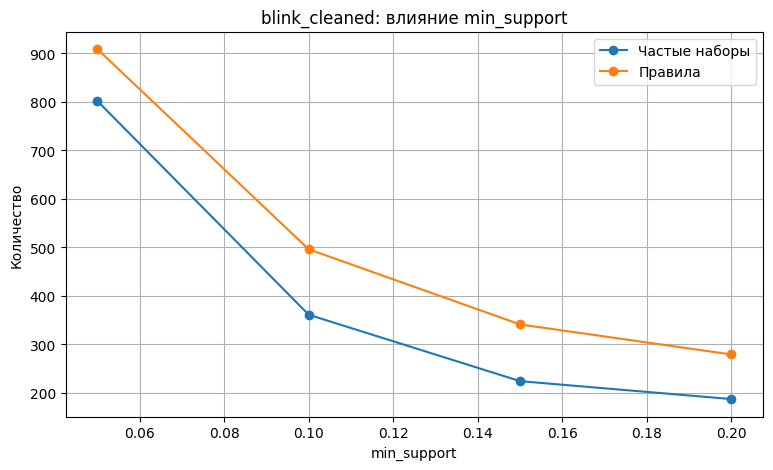

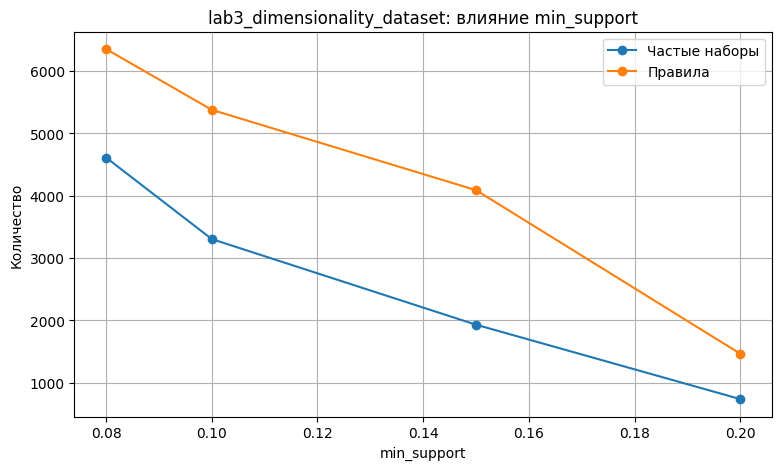

In [12]:
def plot_support_effect(experiment_df, title):
    fixed = experiment_df[experiment_df['min_confidence'] == 0.7].copy()

    plt.figure(figsize=(9, 5))
    plt.plot(fixed['min_support'], fixed['frequent_itemsets'], marker='o', label='Частые наборы')
    plt.plot(fixed['min_support'], fixed['rules'], marker='o', label='Правила')
    plt.xlabel('min_support')
    plt.ylabel('Количество')
    plt.title(title)
    plt.legend()
    plt.show()

plot_support_effect(blink_experiment, 'blink_cleaned: влияние min_support')
plot_support_effect(lab3_experiment, 'lab3_dimensionality_dataset: влияние min_support')

## 12. Топ правил для `blink_cleaned.csv`

Для интерпретации возьмем параметры: `min_support = 0.15`, `min_confidence = 0.7`, `min_lift = 1.0`.

In [13]:
blink_frequent = apriori(blink_transactions, min_support=0.15, max_len=3)
blink_rules = generate_rules(
    blink_frequent,
    min_confidence=0.7,
    min_lift=1.0,
    max_antecedent_len=3,
    max_consequent_len=1
)

print('Количество частых наборов:', len(blink_frequent))
print('Количество правил:', len(blink_rules))

print('\nТоп-10 правил по lift:')
display(rules_to_frame(blink_rules, top_n=10, sort_by='lift'))

print('Топ-10 правил по confidence:')
display(rules_to_frame(blink_rules, top_n=10, sort_by='confidence'))

print('Топ-10 правил по leverage:')
display(rules_to_frame(blink_rules, top_n=10, sort_by='leverage'))

Количество частых наборов: 224
Количество правил: 341

Топ-10 правил по lift:


,antecedent,consequent,support,confidence,lift,conviction,leverage
2,sequenceID=низкий + timestampToA_missing_ind=0,wrap_count=1,0.2368,0.7273,3.0707,2.7982,0.1597
3,sequenceID=низкий + timestampToA_unwrapped=низкий,wrap_count=1,0.2368,0.7273,3.0707,2.7982,0.1597
0,Timestamp ToA_missing_ind=0 + sequenceID=низкий,wrap_count=1,0.2368,0.7273,3.0707,2.7982,0.1597
1,Timestamp ToA_unwrapped=низкий + sequenceID=низкий,wrap_count=1,0.2368,0.7273,3.0707,2.7982,0.1597
26,timestampToA_missing_ind=0 + wrap_count=1,Timestamp ToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585
27,Timestamp ToA_unwrapped=низкий + wrap_count=1,timestampToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585
23,Timestamp ToA_missing_ind=0 + wrap_count=1,timestampToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585
22,Timestamp ToA_missing_ind=0 + wrap_count=1,Timestamp ToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585
21,wrap_count=1,timestampToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585
20,wrap_count=1,Timestamp ToA_unwrapped=низкий,0.2368,1.0000,3.0249,inf,0.1585


Топ-10 правил по confidence:


,antecedent,consequent,support,confidence,lift,conviction,leverage
319,sequenceID=высокий + wrap_count=4,timestampToA_missing_ind=0,0.1957,1.0000,1.0083,inf,0.0016
318,sequenceID=высокий + wrap_count=4,Timestamp ToA_missing_ind=0,0.1957,1.0000,1.0083,inf,0.0016
317,anchorID=ANCH0001 + processed_flag=1,timestampToA_missing_ind=0,0.2039,1.0000,1.0083,inf,0.0017
316,anchorID=ANCH0001 + processed_flag=1,Timestamp ToA_missing_ind=0,0.2039,1.0000,1.0083,inf,0.0017
315,anchorID=ANCH0001 + timestampToA_missing_ind=0,Timestamp ToA_missing_ind=0,0.2188,1.0000,1.0083,inf,0.0018
314,Timestamp ToA_missing_ind=0 + anchorID=ANCH0001,timestampToA_missing_ind=0,0.2188,1.0000,1.0083,inf,0.0018
313,anchorID=ANCH0001,timestampToA_missing_ind=0,0.2188,1.0000,1.0083,inf,0.0018
312,anchorID=ANCH0001,Timestamp ToA_missing_ind=0,0.2188,1.0000,1.0083,inf,0.0018
311,timestampToA_unwrapped=низкий + wrap_count=1,timestampToA_missing_ind=0,0.2368,1.0000,1.0083,inf,0.0019
310,sequenceID=низкий + wrap_count=1,timestampToA_missing_ind=0,0.2368,1.0000,1.0083,inf,0.0019


Топ-10 правил по leverage:


,antecedent,consequent,support,confidence,lift,conviction,leverage
4,Timestamp ToA_unwrapped=низкий,timestampToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
11,timestampToA_missing_ind=0 + timestampToA_unwrapped=низкий,Timestamp ToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
10,Timestamp ToA_unwrapped=низкий + timestampToA_missing_ind=0,timestampToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
9,processed_flag=1 + timestampToA_unwrapped=низкий,Timestamp ToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
8,Timestamp ToA_unwrapped=низкий + processed_flag=1,timestampToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
7,Timestamp ToA_missing_ind=0 + timestampToA_unwrapped=низкий,Timestamp ToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
6,Timestamp ToA_missing_ind=0 + Timestamp ToA_unwrapped=низкий,timestampToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
5,timestampToA_unwrapped=низкий,Timestamp ToA_unwrapped=низкий,0.3306,1.0000,3.0249,inf,0.2213
71,Timestamp ToA_missing_ind=0 + timestampToA_unwrapped=высокий,sequenceID=высокий,0.3306,1.0000,2.9951,inf,0.2202
82,sequenceID=высокий,timestampToA_unwrapped=высокий,0.3306,0.9901,2.9951,67.9449,0.2202


## 13. Топ правил для `lab3_dimensionality_dataset.csv`

Для синтетического датасета возьмем параметры: `min_support = 0.15`, `min_confidence = 0.7`, `min_lift = 1.0`.

In [14]:
lab3_frequent = apriori(lab3_transactions, min_support=0.15, max_len=3)
lab3_rules = generate_rules(
    lab3_frequent,
    min_confidence=0.7,
    min_lift=1.0,
    max_antecedent_len=3,
    max_consequent_len=1
)

print('Количество частых наборов:', len(lab3_frequent))
print('Количество правил:', len(lab3_rules))

print('\nТоп-10 правил по lift:')
display(rules_to_frame(lab3_rules, top_n=10, sort_by='lift'))

print('Топ-10 правил по confidence:')
display(rules_to_frame(lab3_rules, top_n=10, sort_by='confidence'))

print('Топ-10 правил по leverage:')
display(rules_to_frame(lab3_rules, top_n=10, sort_by='leverage'))

Количество частых наборов: 1932
Количество правил: 4090

Топ-10 правил по lift:


,antecedent,consequent,support,confidence,lift,conviction,leverage
0,engagement_index=высокий + monthly_savings=высокий,customer_segment=premium,0.2000,0.8696,3.4783,5.7500,0.1425
1,app_sessions=высокий + monthly_savings=высокий,customer_segment=premium,0.1986,0.8634,3.4534,5.4886,0.1411
2,monthly_savings=высокий + site_visits=высокий,customer_segment=premium,0.1957,0.8457,3.3827,4.8600,0.1379
3,device_score=высокий + monthly_savings=высокий,customer_segment=premium,0.1914,0.8428,3.3711,4.7700,0.1346
4,annual_income=высокий + app_sessions=высокий,customer_segment=premium,0.1943,0.8395,3.3580,4.6731,0.1364
5,monthly_purchases=высокий + monthly_savings=высокий,customer_segment=premium,0.2000,0.8333,3.3333,4.5000,0.1400
6,credit_score=высокий + device_score=высокий,customer_segment=premium,0.1914,0.8323,3.3292,4.4722,0.1339
7,credit_score=высокий + engagement_index=высокий,customer_segment=premium,0.1957,0.8303,3.3212,4.4196,0.1368
8,app_sessions=высокий + credit_score=высокий,customer_segment=premium,0.1943,0.8293,3.3171,4.3929,0.1357
9,annual_income=высокий + engagement_index=высокий,customer_segment=premium,0.1986,0.8274,3.3095,4.3448,0.1386


Топ-10 правил по confidence:


,antecedent,consequent,support,confidence,lift,conviction,leverage
108,monthly_expenses=высокий + monthly_savings=высокий,annual_income=высокий,0.2614,0.9892,2.9846,61.8429,0.1738
109,debt_ratio=низкий + monthly_expenses=высокий,annual_income=высокий,0.2357,0.9880,2.9811,55.8257,0.1566
113,credit_score=высокий + monthly_expenses=высокий,annual_income=высокий,0.2400,0.9825,2.9643,38.1086,0.1590
114,churn_risk=низкий + monthly_expenses=высокий,annual_income=высокий,0.2329,0.9819,2.9627,36.9943,0.1543
115,annual_income=высокий + customer_segment=premium,monthly_savings=высокий,0.2243,0.9813,2.9607,35.6571,0.1485
117,customer_segment=premium + monthly_expenses=высокий,annual_income=высокий,0.2100,0.9800,2.9569,33.4286,0.1390
128,app_sessions=низкий + customer_segment=economy,engagement_index=низкий,0.2014,0.9792,2.9417,32.0229,0.1330
120,annual_income=высокий + credit_score=высокий,monthly_savings=высокий,0.2571,0.9783,2.9516,30.7543,0.1700
122,annual_income=высокий + churn_risk=низкий,monthly_savings=высокий,0.2529,0.9779,2.9506,30.2529,0.1672
123,monthly_expenses=высокий + time_on_platform_months=высокий,annual_income=высокий,0.2500,0.9777,2.9498,29.9186,0.1652


Топ-10 правил по leverage:


,antecedent,consequent,support,confidence,lift,conviction,leverage
629,annual_income=высокий,monthly_expenses=высокий,0.3014,0.9095,2.7207,7.3546,0.1906
630,monthly_expenses=высокий,annual_income=высокий,0.3014,0.9017,2.7207,6.8020,0.1906
911,app_sessions=высокий,engagement_index=высокий,0.2957,0.8922,2.6691,6.1778,0.1849
910,engagement_index=высокий,app_sessions=высокий,0.2957,0.8846,2.6691,5.7943,0.1849
1097,engagement_index=низкий,app_sessions=низкий,0.2900,0.8712,2.6401,5.2037,0.1802
1096,app_sessions=низкий,engagement_index=низкий,0.2900,0.8788,2.6401,5.5039,0.1802
1175,annual_income=низкий,monthly_expenses=низкий,0.2900,0.8750,2.6288,5.3371,0.1797
1176,satisfaction_score=высокий,churn_risk=низкий,0.2900,0.8750,2.6288,5.3371,0.1797
1180,churn_risk=низкий,satisfaction_score=высокий,0.2900,0.8712,2.6288,5.1926,0.1797
1179,monthly_expenses=низкий,annual_income=низкий,0.2900,0.8712,2.6288,5.1926,0.1797


## 14. Сравнение производительности Apriori и FP-Growth на рабочих датасетах

Сравним время выполнения двух реализаций на `blink_cleaned` и `lab3_dimensionality_dataset` при одинаковых параметрах.

,dataset,transactions,min_support,max_len,apriori_itemsets,fp_growth_itemsets,same_itemsets,apriori_time_sec,fp_growth_time_sec
0,blink_cleaned,608,0.1500,3,224,224,True,0.0324,0.0090
1,lab3_dimensionality_dataset,700,0.1500,3,1932,1932,True,0.3263,0.2804


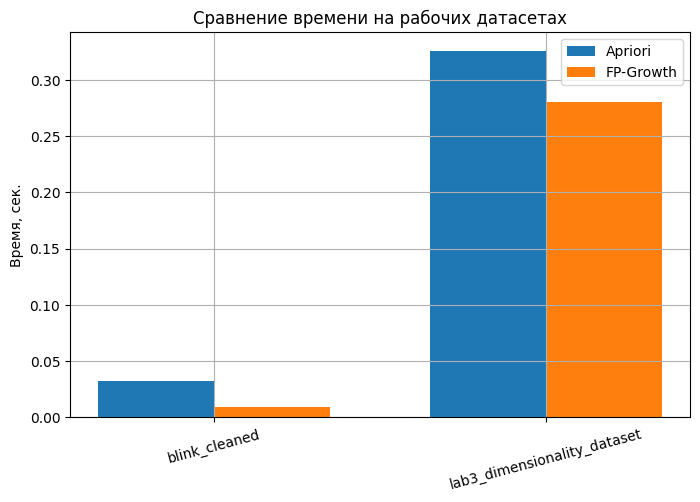

In [15]:
def compare_algorithms_on_dataset(name, transactions, min_support=0.15, max_len=3):
    """Измеряет время Apriori и FP-Growth на одном датасете."""
    start = time.perf_counter()
    ap_itemsets = apriori(transactions, min_support=min_support, max_len=max_len)
    ap_time = time.perf_counter() - start

    start = time.perf_counter()
    fp_itemsets = fpgrowth(transactions, min_support=min_support, max_len=max_len)
    fp_time = time.perf_counter() - start

    return {
        'dataset': name,
        'transactions': len(transactions),
        'min_support': min_support,
        'max_len': max_len,
        'apriori_itemsets': len(ap_itemsets),
        'fp_growth_itemsets': len(fp_itemsets),
        'same_itemsets': set(ap_itemsets.keys()) == set(fp_itemsets.keys()),
        'apriori_time_sec': ap_time,
        'fp_growth_time_sec': fp_time
    }

comparison_real = pd.DataFrame([
    compare_algorithms_on_dataset('blink_cleaned', blink_transactions, min_support=0.15, max_len=3),
    compare_algorithms_on_dataset('lab3_dimensionality_dataset', lab3_transactions, min_support=0.15, max_len=3)
])

display(comparison_real)

plt.figure(figsize=(8, 5))
x = np.arange(len(comparison_real))
width = 0.35
plt.bar(x - width/2, comparison_real['apriori_time_sec'], width, label='Apriori')
plt.bar(x + width/2, comparison_real['fp_growth_time_sec'], width, label='FP-Growth')
plt.xticks(x, comparison_real['dataset'], rotation=15)
plt.ylabel('Время, сек.')
plt.title('Сравнение времени на рабочих датасетах')
plt.legend()
plt.show()

## 15. Сравнение производительности на синтетических транзакционных данных

Для отдельного сравнения производительности сгенерируем настоящие транзакционные данные: каждая транзакция — случайный набор элементов `I000`, `I001`, ...

В генератор добавлены повторяющиеся паттерны, чтобы в данных действительно были ассоциации:

- пара `I000`, `I001` встречается совместно с повышенной вероятностью;
- тройка `I002`, `I003`, `I004` также добавляется совместно с повышенной вероятностью.

In [16]:
def generate_synthetic_transactions(n_transactions, n_items=80, avg_len=5, random_seed=42):
    """Генерирует синтетические транзакции с несколькими встроенными паттернами."""
    rng = random.Random(random_seed)
    items = [f'I{i:03d}' for i in range(n_items)]
    transactions = []

    for _ in range(n_transactions):
        length = int(rng.gauss(avg_len, max(1, avg_len / 3)))
        length = max(1, min(n_items, length))
        transaction = set(rng.sample(items, length))

        if rng.random() < 0.25:
            transaction.update(['I000', 'I001'])
        if rng.random() < 0.15:
            transaction.update(['I002', 'I003', 'I004'])

        transactions.append(transaction)

    return transactions


def benchmark_algorithms(transactions, min_support=0.05, max_len=2):
    """Измеряет время Apriori и FP-Growth."""
    start = time.perf_counter()
    ap_itemsets = apriori(transactions, min_support=min_support, max_len=max_len)
    ap_time = time.perf_counter() - start

    start = time.perf_counter()
    fp_itemsets = fpgrowth(transactions, min_support=min_support, max_len=max_len)
    fp_time = time.perf_counter() - start

    return {
        'apriori_time_sec': ap_time,
        'fp_growth_time_sec': fp_time,
        'apriori_itemsets': len(ap_itemsets),
        'fp_growth_itemsets': len(fp_itemsets),
        'same_itemsets': set(ap_itemsets.keys()) == set(fp_itemsets.keys())
    }

### 15.1. Зависимость времени от числа транзакций

Используем размеры `N = 1000, 5000, 10000, 20000, 50000`.

Чтобы эксперимент был воспроизводимым и не занимал слишком много времени, для этого графика фиксируем среднюю длину транзакции `avg_len = 5` и ищем наборы длиной до 2 элементов.

,apriori_time_sec,fp_growth_time_sec,apriori_itemsets,fp_growth_itemsets,same_itemsets,n_transactions,avg_len
0,0.0144,0.1536,74,74,True,1000,5
1,0.0556,0.1760,88,88,True,5000,5
2,0.0935,0.8370,89,89,True,10000,5
3,0.1779,3.9204,90,90,True,20000,5
4,0.4875,29.6397,90,90,True,50000,5


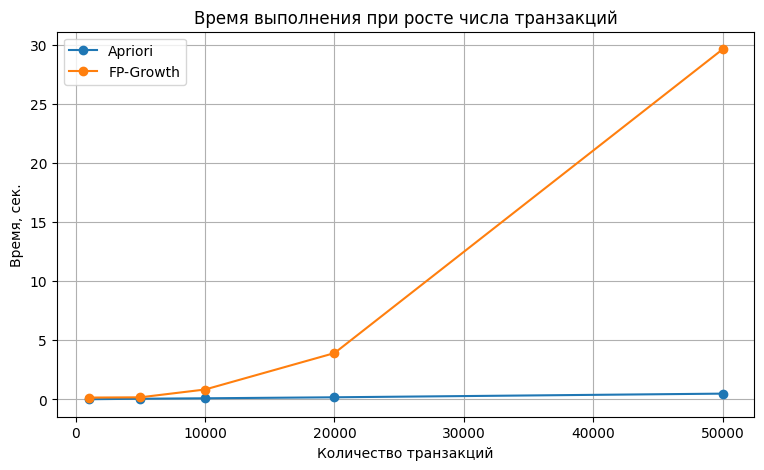

In [17]:
transaction_sizes = [1000, 5000, 10000, 20000, 50000]
benchmark_by_size = []

for n in transaction_sizes:
    synthetic_transactions = generate_synthetic_transactions(
        n_transactions=n,
        n_items=80,
        avg_len=5,
        random_seed=RANDOM_SEED + n
    )
    result = benchmark_algorithms(synthetic_transactions, min_support=0.05, max_len=2)
    result['n_transactions'] = n
    result['avg_len'] = 5
    benchmark_by_size.append(result)

benchmark_by_size = pd.DataFrame(benchmark_by_size)
display(benchmark_by_size)

plt.figure(figsize=(9, 5))
plt.plot(benchmark_by_size['n_transactions'], benchmark_by_size['apriori_time_sec'], marker='o', label='Apriori')
plt.plot(benchmark_by_size['n_transactions'], benchmark_by_size['fp_growth_time_sec'], marker='o', label='FP-Growth')
plt.xlabel('Количество транзакций')
plt.ylabel('Время, сек.')
plt.title('Время выполнения при росте числа транзакций')
plt.legend()
plt.show()

### 15.2. Зависимость времени от средней длины транзакции

Теперь фиксируем `N = 5000` и сравним средние длины транзакций `5`, `10`, `20`.

,apriori_time_sec,fp_growth_time_sec,apriori_itemsets,fp_growth_itemsets,same_itemsets,n_transactions,avg_len
0,0.0228,0.0256,9,9,True,5000,5
1,0.1434,1.7614,84,84,True,5000,10
2,0.4885,10.9148,238,238,True,5000,20


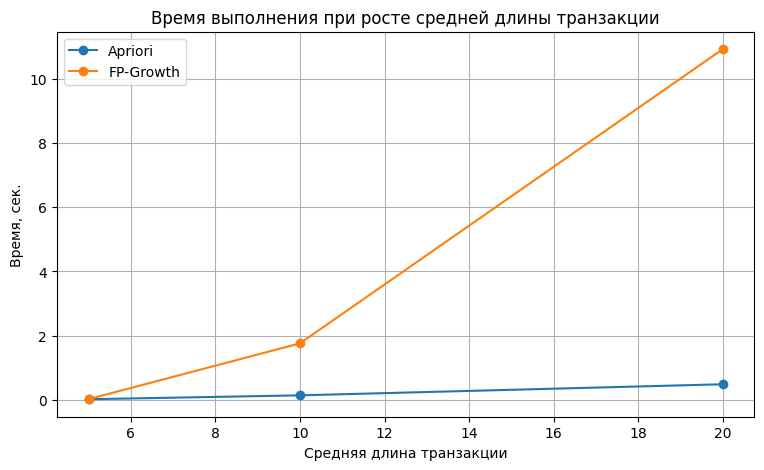

In [18]:
avg_lengths = [5, 10, 20]
benchmark_by_length = []

for avg_len in avg_lengths:
    synthetic_transactions = generate_synthetic_transactions(
        n_transactions=5000,
        n_items=80,
        avg_len=avg_len,
        random_seed=RANDOM_SEED + avg_len
    )
    result = benchmark_algorithms(synthetic_transactions, min_support=0.10, max_len=2)
    result['n_transactions'] = 5000
    result['avg_len'] = avg_len
    benchmark_by_length.append(result)

benchmark_by_length = pd.DataFrame(benchmark_by_length)
display(benchmark_by_length)

plt.figure(figsize=(9, 5))
plt.plot(benchmark_by_length['avg_len'], benchmark_by_length['apriori_time_sec'], marker='o', label='Apriori')
plt.plot(benchmark_by_length['avg_len'], benchmark_by_length['fp_growth_time_sec'], marker='o', label='FP-Growth')
plt.xlabel('Средняя длина транзакции')
plt.ylabel('Время, сек.')
plt.title('Время выполнения при росте средней длины транзакции')
plt.legend()
plt.show()

## 16. Визуализация ассоциативных правил

Построим три вида визуализации:

1. граф ассоциаций;
2. heatmap матрицы `lift` для одиночных правил;
3. диаграмму рассеяния `support-confidence` с цветом по `lift`.

Для визуализации возьмем правила из синтетического датасета `lab3_dimensionality_dataset`, потому что там правила лучше интерпретируются через сегменты клиентов и уровни признаков.

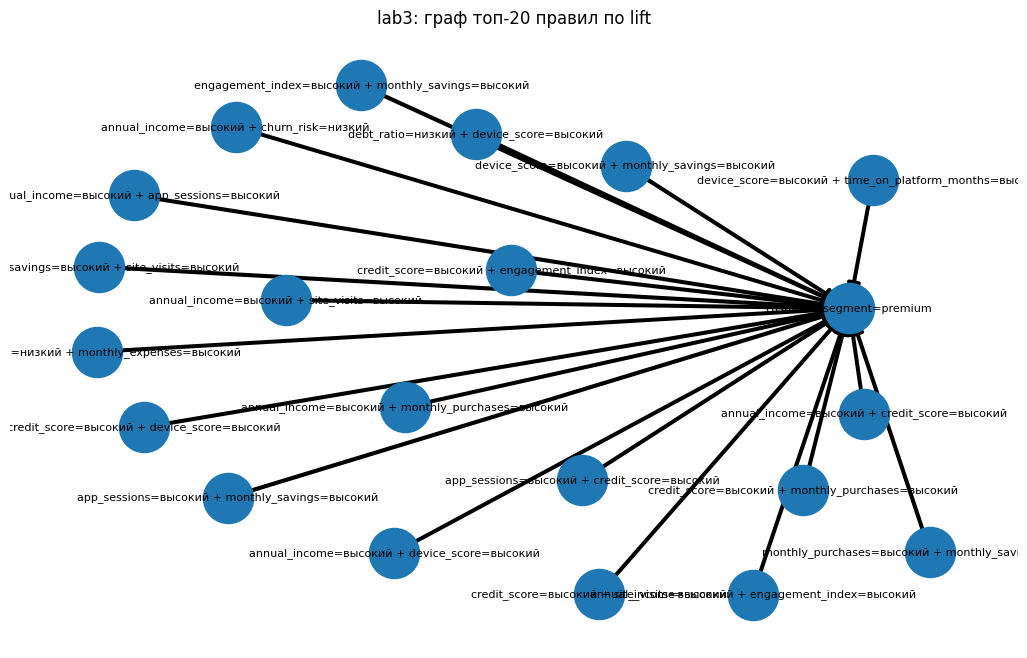

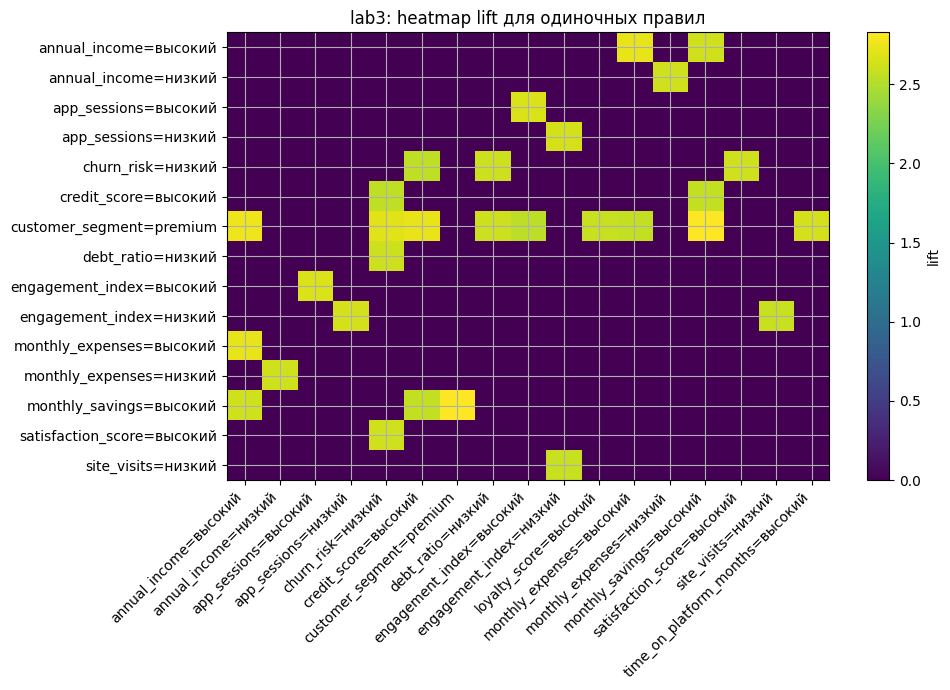

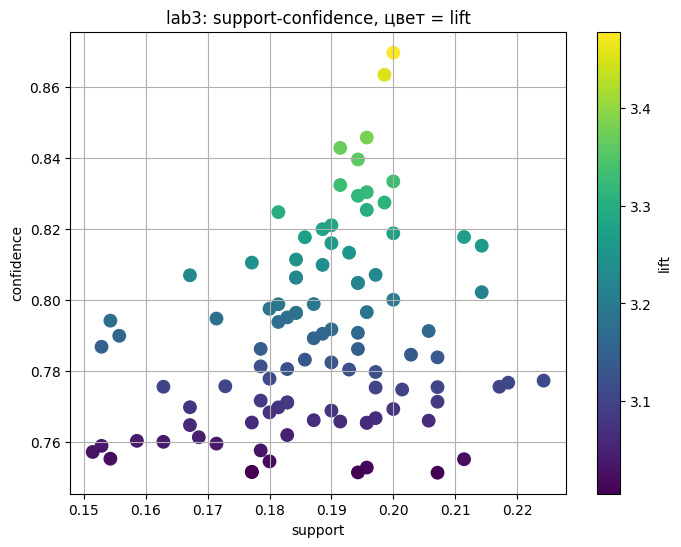

In [19]:
def plot_rule_graph(rules, top_n=25, sort_by='lift', title='Граф ассоциативных правил'):
    """Строит направленный граф правил."""
    df_rules = rules_to_frame(rules, top_n=top_n, sort_by=sort_by)
    if df_rules.empty:
        print('Нет правил для визуализации.')
        return

    G = nx.DiGraph()
    for _, row in df_rules.iterrows():
        left = row['antecedent']
        right = row['consequent']
        G.add_edge(left, right, weight=row['lift'], confidence=row['confidence'])

    plt.figure(figsize=(13, 8))
    pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.8)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    widths = [1 + 2 * (w / max(weights)) for w in weights]

    nx.draw_networkx_nodes(G, pos, node_size=1300)
    nx.draw_networkx_edges(G, pos, arrows=True, width=widths, arrowstyle='-|>', arrowsize=18)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis('off')
    plt.show()


def plot_lift_heatmap(rules, top_n=30, title='Матрица lift'):
    """Строит heatmap lift для правил с одиночной левой и правой частью."""
    single_rules = [r for r in rules if len(r['antecedent']) == 1 and len(r['consequent']) == 1]
    df_rules = rules_to_frame(single_rules, top_n=top_n, sort_by='lift')
    if df_rules.empty:
        print('Нет одиночных правил для heatmap.')
        return

    pivot = df_rules.pivot_table(index='antecedent', columns='consequent', values='lift', aggfunc='max')

    plt.figure(figsize=(10, 7))
    im = plt.imshow(pivot.fillna(0).values, aspect='auto')
    plt.colorbar(im, label='lift')
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_support_confidence_scatter(rules, top_n=100, title='Support-Confidence-Lift'):
    """Строит scatter plot правил в координатах support-confidence."""
    df_rules = rules_to_frame(rules, top_n=top_n, sort_by='lift')
    if df_rules.empty:
        print('Нет правил для scatter plot.')
        return

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df_rules['support'], df_rules['confidence'], c=df_rules['lift'], s=80)
    plt.colorbar(scatter, label='lift')
    plt.xlabel('support')
    plt.ylabel('confidence')
    plt.title(title)
    plt.show()

plot_rule_graph(lab3_rules, top_n=20, sort_by='lift', title='lab3: граф топ-20 правил по lift')
plot_lift_heatmap(lab3_rules, top_n=30, title='lab3: heatmap lift для одиночных правил')
plot_support_confidence_scatter(lab3_rules, top_n=100, title='lab3: support-confidence, цвет = lift')

## 17. Интерпретация результатов

### `blink_cleaned.csv`

В датасете `blink_cleaned.csv` найденные правила в основном отражают техническую структуру измерений:

1. Сильные правила часто связаны с временными группами `sequenceID`, `Timestamp ToA_unwrapped`, `timestampToA_unwrapped` и `wrap_count`.
2. Это логично, потому что `wrap_count` был получен при разворачивании временного счетчика, а значит он связан с диапазонами последовательностей и временных меток.
3. Правила с индикаторами пропусков нужно интерпретировать осторожно. Если один из индикаторов почти всегда равен 0, то такие правила могут иметь высокую `confidence`, но быть малоинформативными.

Практический смысл для этого датасета: ассоциативные правила могут показать, какие технические состояния измерений часто встречаются вместе. Например, связь между диапазоном `sequenceID` и `wrap_count` подтверждает, что разворачивание временной метки связано с номером последовательности.

### `lab3_dimensionality_dataset.csv`

В синтетическом датасете правила лучше интерпретируются как клиентские профили. Например, в топе правил встречаются связи вида:

- высокий `monthly_savings` и высокий `engagement_index` связаны с сегментом `premium`;
- высокий `churn_risk` связан с сегментом `risk_group`;
- высокие показатели активности могут быть связаны с более лояльным или премиальным сегментом.

Так как датасет синтетический, эти связи не следует трактовать как реальные бизнес-закономерности. Они показывают, что алгоритмы корректно выделяют повторяющиеся сочетания признаков.

### Почему высокий lift не всегда означает полезное правило

Правило может иметь высокий `lift`, но быть бесполезным, если:

1. оно основано на очень редких элементах;
2. оно является очевидным из способа подготовки данных;
3. оно связывает производные признаки, которые были созданы друг из друга;
4. оно не дает нового предметного знания.

Поэтому правила нужно оценивать не только по `lift`, но и по `support`, `confidence`, `leverage` и предметному смыслу.

## 18. Вывод

При увеличении `min_support` количество частых наборов и правил уменьшается. Apriori проще реализовать и хорошо работает на небольших данных, но при росте числа элементов и длины транзакций количество кандидатов быстро увеличивается. FP-Growth избегает прямой генерации большого числа кандидатов, но в учебной реализации его скорость зависит от структуры FP-дерева и количества условных деревьев.